In [47]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import RNN,LSTM,GRU
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
import torch.nn.utils as utils
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,roc_auc_score

## Model Training and evaluation 

In [52]:
X=np.load("../data/X.npy")
y=np.load("../data/y.npy")

In [53]:
print(X.shape,y.shape)

(170, 100, 2) (170,)


In [59]:
class KeystrokeDynamics(Dataset):

    def __init__(self,X,y):
        super().__init__()

        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)

    def __len__(self):

        assert len(self.X) == len(self.y), "x and y must have the same length"
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    

In [60]:
class Keystroke_Model(nn.Module):

    def __init__(self, model_type,dropout=0.3,input_size=2,hidden_size=128,num_layers=2):
        super().__init__()

        if model_type=="RNN":
            self.model=nn.RNN(input_size,hidden_size,num_layers,batch_first=True,bidirectional=True)

        elif model_type=="LSTM":
            self.model=nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,bidirectional=True)

        elif model_type=="GRU":
            self.model=nn.GRU(input_size,hidden_size,num_layers,batch_first=True,bidirectional=True)
        else:
            print('Invalid Model Type.')
        self.dropout=nn.Dropout(dropout)
        self.fc=nn.Linear(hidden_size*2,1)

    def forward(self,X):

        out,_=self.model(X)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)

        return out

In [63]:
def train_model(model_type, epochs=60,lr=0.005,seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("X shape:", np.shape(X))
    print("y shape:", np.shape(y))
    print("len X:", len(X))
    print("len y:", len(y))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y,random_state=seed
    )

    train_ds=KeystrokeDynamics(X_train,y_train)
    test_ds=KeystrokeDynamics(X_test,y_test)

    train_loader=DataLoader(train_ds,batch_size=32,shuffle=True)
    test_loader=DataLoader(test_ds,batch_size=32)

    model = Keystroke_Model(model_type=model_type)
    
    pos_weights=torch.tensor(
        len(y_train[y_train==0])/max(1,len(y_train[y_train==1])),
        dtype=torch.float
    )

    criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer=optim.Adam(model.parameters(),lr=lr)

    train_losses=[]

    for epoch in range(epochs):
        
        model.train()
        epoch_loss = 0
        num_batches = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()
            logits=model(xb).squeeze()
            loss=criterion(logits,yb)
            loss.backward()

            # gradient clipping:- 
            utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            optimizer.step()

            epoch_loss +=loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"[{model_type}] Epoch {epoch+1}/{epochs}   loss: {avg_loss:.4f}")

    plt.plot(train_losses)
    plt.title(f"{model_type} Training Loss (seed {seed})")
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.show()
    
    model.eval()
    probs = []
    with torch.no_grad():
        for batch_x,_ in test_loader:
            logits = model(batch_x).squeeze()
            prob=torch.sigmoid(logits).cpu().numpy()
            probs.extend(prob)
    probs = np.array(probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    eer_idx = np.nanargmin(np.abs(fpr - (1 - tpr)))
    eer = fpr[eer_idx]
    auc = roc_auc_score(y_test, probs)
    print(f"{model_type} - AUC: {auc:.4f}  EER: {eer:.4f}")

    return auc,eer



X shape: (170, 100, 2)
y shape: (170,)
len X: 170
len y: 170


[RNN] Epoch 10/80   loss: 0.5044
[RNN] Epoch 20/80   loss: 0.3913
[RNN] Epoch 30/80   loss: 0.3924
[RNN] Epoch 40/80   loss: 0.3934
[RNN] Epoch 50/80   loss: 0.3592
[RNN] Epoch 60/80   loss: 0.3427
[RNN] Epoch 70/80   loss: 0.3130
[RNN] Epoch 80/80   loss: 0.2714


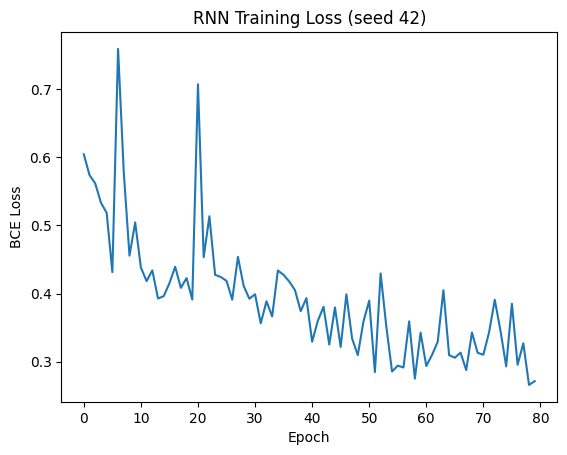

RNN - AUC: 0.7088  EER: 0.4000


TypeError: cannot unpack non-iterable NoneType object

In [62]:
for m_type in ['RNN', 'LSTM', 'GRU']:
    auc, eer = train_model(m_type, epochs=80, lr=0.0005, seed=42)

In [ ]:
def load_model(model_type):
    model = KeystrokeRNN(model_type=model_type)
    model_filename = f'{model_type}_model.pth'
    model.load_state_dict(torch.load(model_filename))
    model.eval() # Set the model to evaluation mode
    print(f"Model {model_type} loaded from {model_filename}")
    return model

loaded_models = {}
for m_type in ['RNN', 'LSTM', 'GRU']:
    loaded_models[m_type] = load_model(m_type)

print("\nAll models loaded successfully.")